# Análisis de Datos Poblacionales en la Ciudad de Boston

Se nos pide realizar un análisis de datos sobre los precios del mercado de viviendas en la ciudad de Boston `median_value`, Así como datos adicionales sobre la ubicación de al vivienda y otros datos sociodemográficos.

## Load Data and Libraries

Cargamos la data .csv y las librerías necesarias para el análisis, visualización de datos para cumplir con los objetivos solicitados en el primer entregable de MD004.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

# Data visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('darkgrid')
# set options to display all columns
pd.set_option('display.max_columns', None)

# Seed for reproducibility
seed = 2026

In [2]:
# Load data
data = pd.read_csv('../data/20230119_DatosBoston.csv', sep = ';')

## 1. Análisis exploratorio de los datos.

El proveedor de los datos suministra una descripción de cada una de las valiables del dataset.

* `crime_index`: Índice de criminalidad de la zona
* `urban_ratio`: Ratio de zona urbana residencial sobre el total
* `industry_ratio`: Ratio de industria de la zona
* `c_river_variable`: 1 si la zona colinda con un río y 0 si no
* `nox_concentration`: Concentración de óxido nitroso en la zona
* `rooms_per_dwelling`: Número de habitaciones medio por vivienda
* `dwelling_age`: “Edad” media de la vivienda
* `dwelling_dist`: Distancia media ponderada con los centros urbanos de la ciudad
* `highway_index`: Índice de accesibilidad sobre autopistas cercanas
* `tax_ratio`: Índice de tasas por cada 10000usd
* `teacher_ratio`: Ratio de alumno por profesor
* `racial_index`: Índice de proporción de población no caucásica
* `lower_status`: Porcentaje de población de “clase-baja”
* `median_value`: Valor medio de precio de la vivienda (En 1000USD)

Vamos a realizar un analisis exploratorio de los datos, para entender la distribución de cada una de las variables, y posterior realizar un análisis de correlación entre las variables para entender la relación entre ellas y el precio de la vivienda `median_value`.

### 1.1 SHAPE, INFO y Estadísticos descriptivos

Iniciemos con una revisión del tamaño de la data y veamos los estadísticos descriptivos principales.

In [3]:
# Show Shape and INFO
print('Shape of the data (rows, columns): ', data.shape)
print('\nInfo of the data: ')
data.info()

Shape of the data (rows, columns):  (506, 14)

Info of the data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   crime_index         506 non-null    float64
 1   urban_ratio         506 non-null    float64
 2   industry_ratio      506 non-null    float64
 3   c_river_variable    506 non-null    int64  
 4   nox_concentration   506 non-null    float64
 5   rooms_per_dwelling  506 non-null    float64
 6   dwelling_age        506 non-null    float64
 7   dwelling_dist       506 non-null    float64
 8   highway_index       506 non-null    int64  
 9   tax_ratio           506 non-null    int64  
 10  teacher_ratio       506 non-null    float64
 11  racial_index        506 non-null    float64
 12  lower_status        506 non-null    float64
 13  median_value        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 5

In [4]:
# Show Head and Tail data
print('Head of the data: ')
display(data.head(3))
print('\nTail of the data: ')
display(data.tail(3))

Head of the data: 


,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.090,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,49.671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,49.671,2,242,17.8,392.83,4.03,34.7



Tail of the data: 


,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,21.675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,23.889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.505,1,273,21.0,396.90,7.88,11.9


Datos estadísticos descriptivos:

In [5]:
# Description Data
data.describe()

,crime_index,urban_ratio,industry_ratio,c_river_variable,nox_concentration,rooms_per_dwelling,dwelling_age,dwelling_dist,highway_index,tax_ratio,teacher_ratio,racial_index,lower_status,median_value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,131.695678,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,33.836573,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,246.395746,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,22.912317,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.137000,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,17.930000,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,27.533000,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,143.337000,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,47.648250,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,996.654000,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,121.265000,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Existe una única variable categórica `c_river_variable`, por tanto no hace falta realizar una conversión en el tipo de dato ni hacer Dummy encoding. El resto de valores son de coma flotante o int64 y además, no existen valores nulos en el dataset, por lo que no es necesario realizar una limpieza de datos.

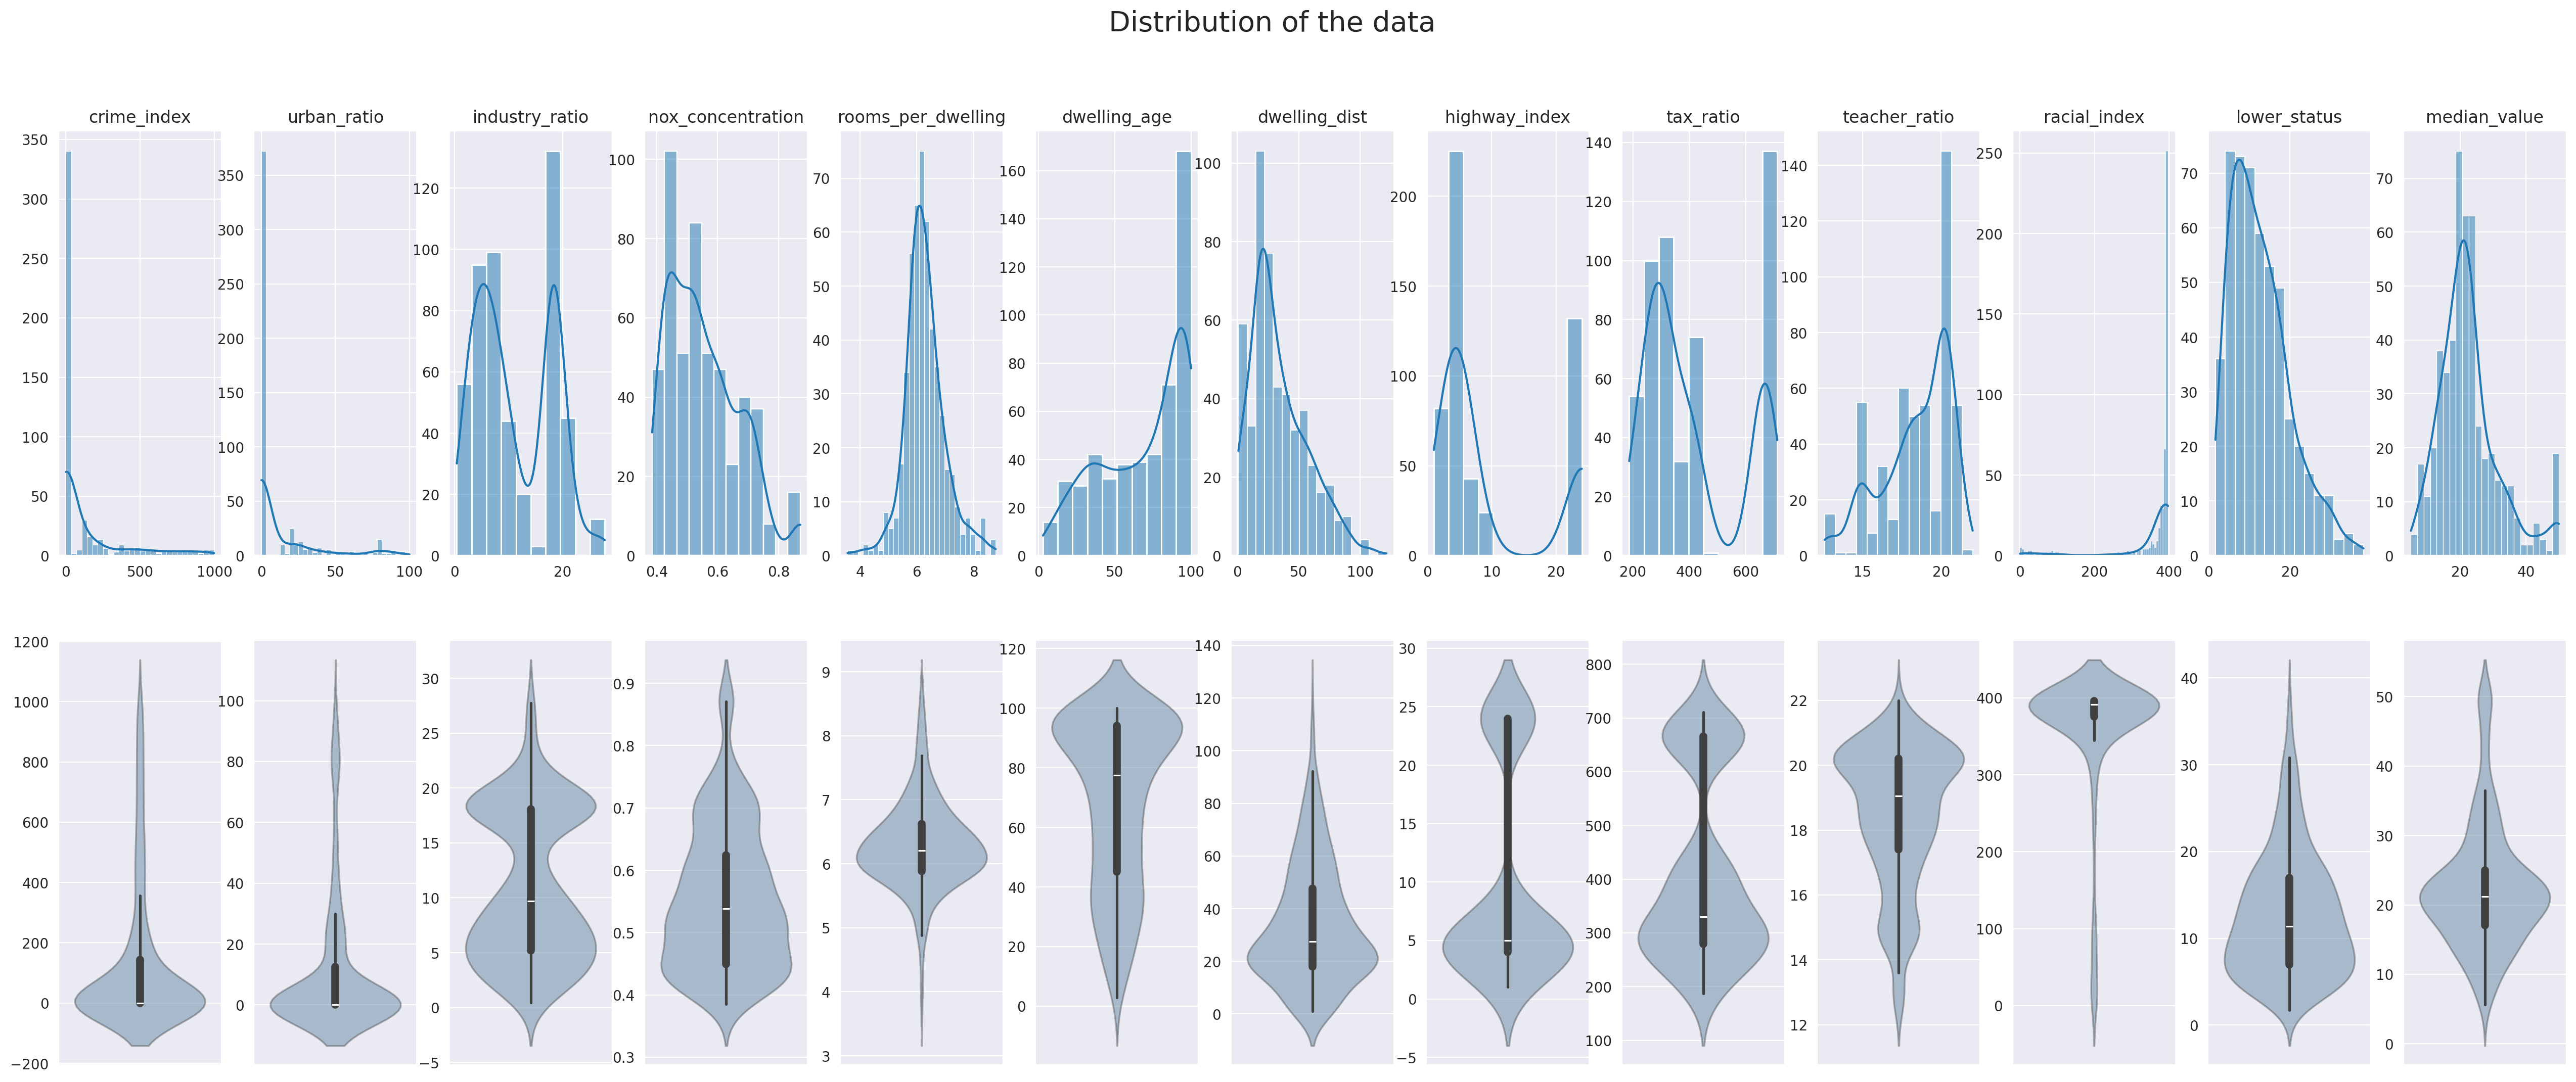

In [ ]:
# First, get columns that is categoryical
# In this DataSet, c_river_variable is categorical variable.(lebel encoded)
categorical_cols = ['c_river_variable']

data_float = data.drop(columns=categorical_cols).copy()
fig, ax = plt.subplots(figsize=(32, 12), ncols = data_float.shape[1], nrows = 2, dpi=200)

for i, col in enumerate(data_float.columns):
    sns.histplot(data_float[col], ax = ax[0, i], kde = True)
    ax[0, i].set_title(col, fontsize = 12)
    ax[0, i].set_xlabel('')
    ax[0, i].set_ylabel('')
    # set fontsize in y ticks
    ax[0, i].tick_params(axis='y', labelsize=10)
    ax[0, i].tick_params(axis='x', labelsize=10)

    # boxlot in row =2 in vertical
    sns.violinplot(data_float[col], ax = ax[1, i], orient = 'v', saturation= 0.5, alpha = 0.4)
    ax[1, i].set_xlabel('')
    ax[1, i].set_ylabel('')

plt.suptitle('Distribution of the data', fontsize = 20)

plt.show()

Muy bien, esta visualizacion es muy intuitiva. Podemos ver claramente la distribucion con el KDE kernel de la densidad de la distribución en la primera fila. En la segunda fila, se muestra con un violinplot como se concentran los puntos a lo largo del rango de valores, vemos como se estilan claramente las colas y la mediana.

Podemos ver como `rooms_per_dwelling` parece serguir una distribución muy cercana a la normal, la variable objetivo `median_value` tambien tiene una distribución cercana a la normal aunque con cierto ourlier en valores altos.También podemos observar como `crime_index` y `urban_ratio` parecen tener muchos valores cercanos a cero, basicamente una tasa de criminalidad muy baja, pero tambien tasa de urbanismo muy baja tambien. Las variables de `tax_ratio` y `highway_index` tienen un cumulo importante de valores a la derecha, lo que indica casas en zonas con tasas altas y otras con alta accesibilidad a autopistas peor un un vacio importante de valores en la parte baja.

El resto de variables tiene claros sesgos de cola de derecha o de izquierda. Analicemos nuestra variable objetivo `median_value` con más detalle, para entender su distribución y posibles outliers mediante un QQ plot.

Median value:  21.2


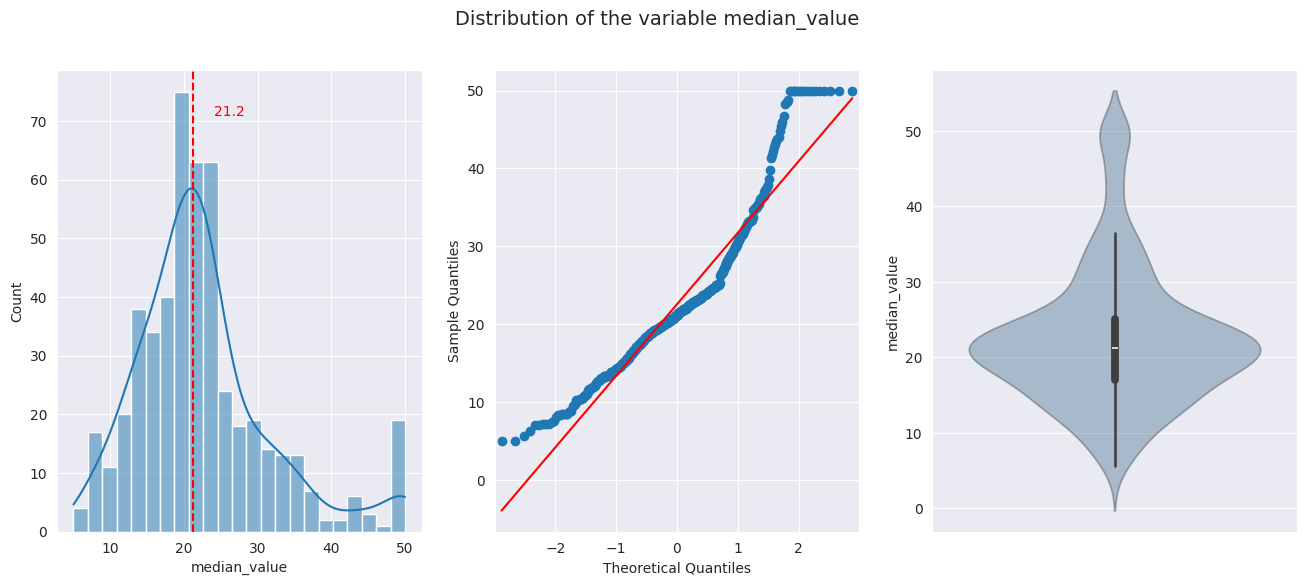

In [7]:
import statsmodels.api as sm

## QQ Plot
fig, ax = plt.subplots(figsize=(16, 6), dpi=100, ncols = 3)

sns.histplot(data['median_value'], kde = True, ax = ax[0])
ax[0].axvline(data['median_value'].median(), color='red', linestyle='--', label='Median')
# Add label text
ax[0].text(data['median_value'].median() + 5, ax[0].get_ylim()[1]*0.9, data['median_value'].median(), color='red', fontsize=10, ha='center')

sm.qqplot(data['median_value'], line = 's', ax = ax[1])
sns.violinplot(data['median_value'], orient = 'v', saturation= 0.5, alpha = 0.4, ax = ax[2])

# Print Median value
print('Median value: ', data['median_value'].median())



plt.suptitle('Distribution of the variable median_value', fontsize = 14)

plt.show()

Sin duda alguna, requiere un ajuste para normalizar la variable objetivo `media_value`, por ello no podemos determinar si se trata de viviendas de lujo o no. Esto puede ser comun en mercado inmobiliarios pero distorsionan la medicion. Tambien pueden indicar presencia de outliers, lo que puede afectar negativamente modelos posteriores.

Adicionalmente, se pueden observar truncamients en `media_value` en valores aproximados de ~50, los cuales no representan necesariamente los outliers reales, si no una limitación propia del dataset.

Sin duda, lo mas óptimo antes de realizar cualquier modelo de regresión, es realizar una transformación a la variable objetivo para terminar de ajustarla a una distribucón mas parecida a la normal. Entre las opciones puede ser una transformación logarítimica o Box-Cox.

Median value:  4.33
Lambda value:  0.22


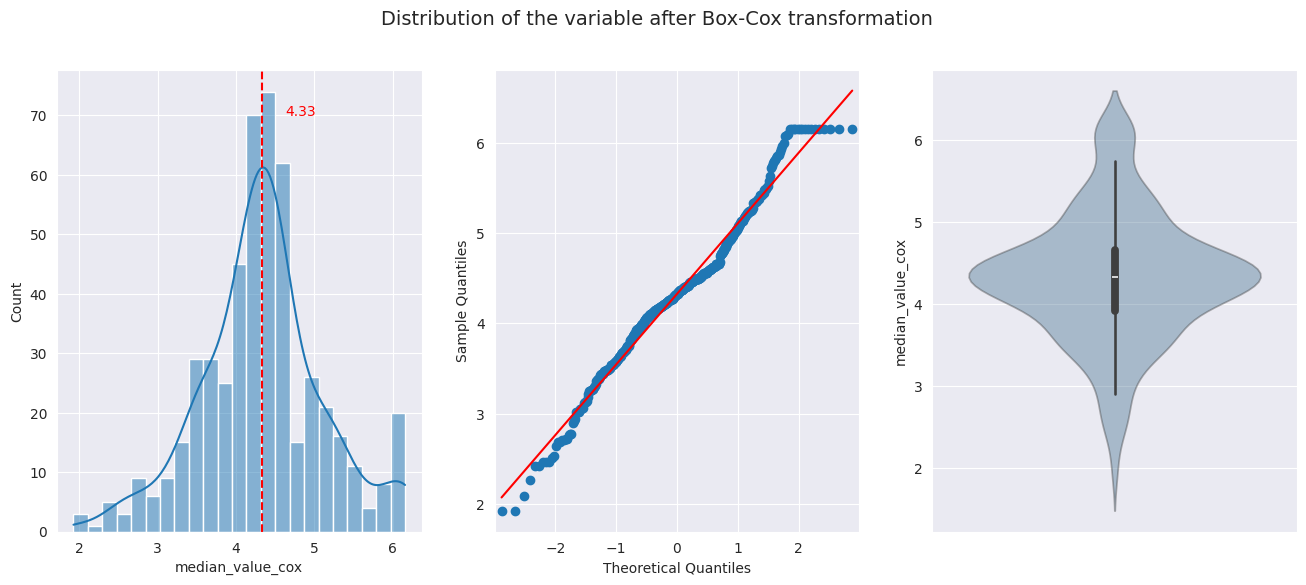

In [8]:
from scipy import stats

data['median_value_cox'], lambda_cox = stats.boxcox(data['median_value'])

fig, ax = plt.subplots(figsize=(16, 6), dpi=100, ncols = 3)

sns.histplot(data['median_value_cox'], kde = True, ax = ax[0])
ax[0].axvline(data['median_value_cox'].median(), color='red', linestyle='--', label='Median')
# Add label text
ax[0].text(data['median_value_cox'].median() + 0.5, ax[0].get_ylim()[1]*0.9, np.round(data['median_value_cox'].median(), 2), color='red', fontsize=10, ha='center')

sm.qqplot(data['median_value_cox'], line = 's', ax = ax[1])
sns.violinplot(data['median_value_cox'], orient = 'v', saturation= 0.5, alpha = 0.4, ax = ax[2])

# Print Median value
print('Median value: ', np.round(data['median_value_cox'].median(), 2))
print('Lambda value: ', np.round(lambda_cox, 2))



plt.suptitle('Distribution of the variable after Box-Cox transformation', fontsize = 14)

plt.show()

Esta transofrmación por Box-Cox soluciona la asimetría, pero no oculta del todo la presencia de Outliers. Valdría la pena realizar un análisis de outliers para determinar si es necesario eliminar algunos de ellos o no, dependiendo del modelo que se quiera utilizar posteriormente. En el momento de realizar el modelo de regresión, se harán pruebas del modelo para determinar como quedan los residuos y si eliminando algunos de estos outliers se mejora el modelo o no.

Se ha utilizado $\lambda = 0.216$ para la transformación de Box-Cox. Este es valor mas optimo que se estima bajo máxima verosimilitud. S trata de un punto intermedio entre una transformación logarítmica y una raiz.

### 1.2 Análisis de correlación

Ahora vamos a explorar como se relacionan las variables entre sí, tanto entre las variables predictoras como con la variable objetivo. Para esto, vamos a utilizar un mapa de calor de correlación y un pairplot para visualizar las relaciones entre las variables.

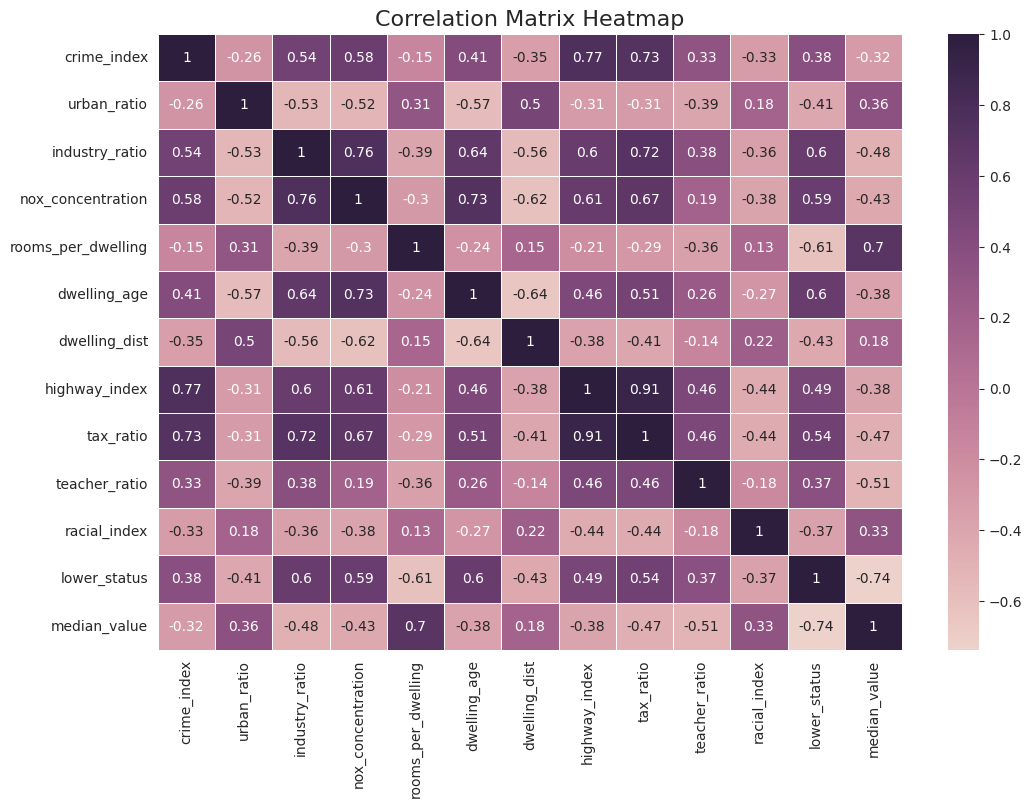

In [9]:
# Extract correlaction matrix
corr_matrix = data_float.corr()

# Plot heatmap
plt.figure(figsize=(12, 8), dpi=100)
sns.heatmap(corr_matrix, annot = True, cmap=sns.cubehelix_palette(as_cmap=True), linewidths = 0.5)
plt.title('Correlation Matrix Heatmap', fontsize = 16)
plt.show()

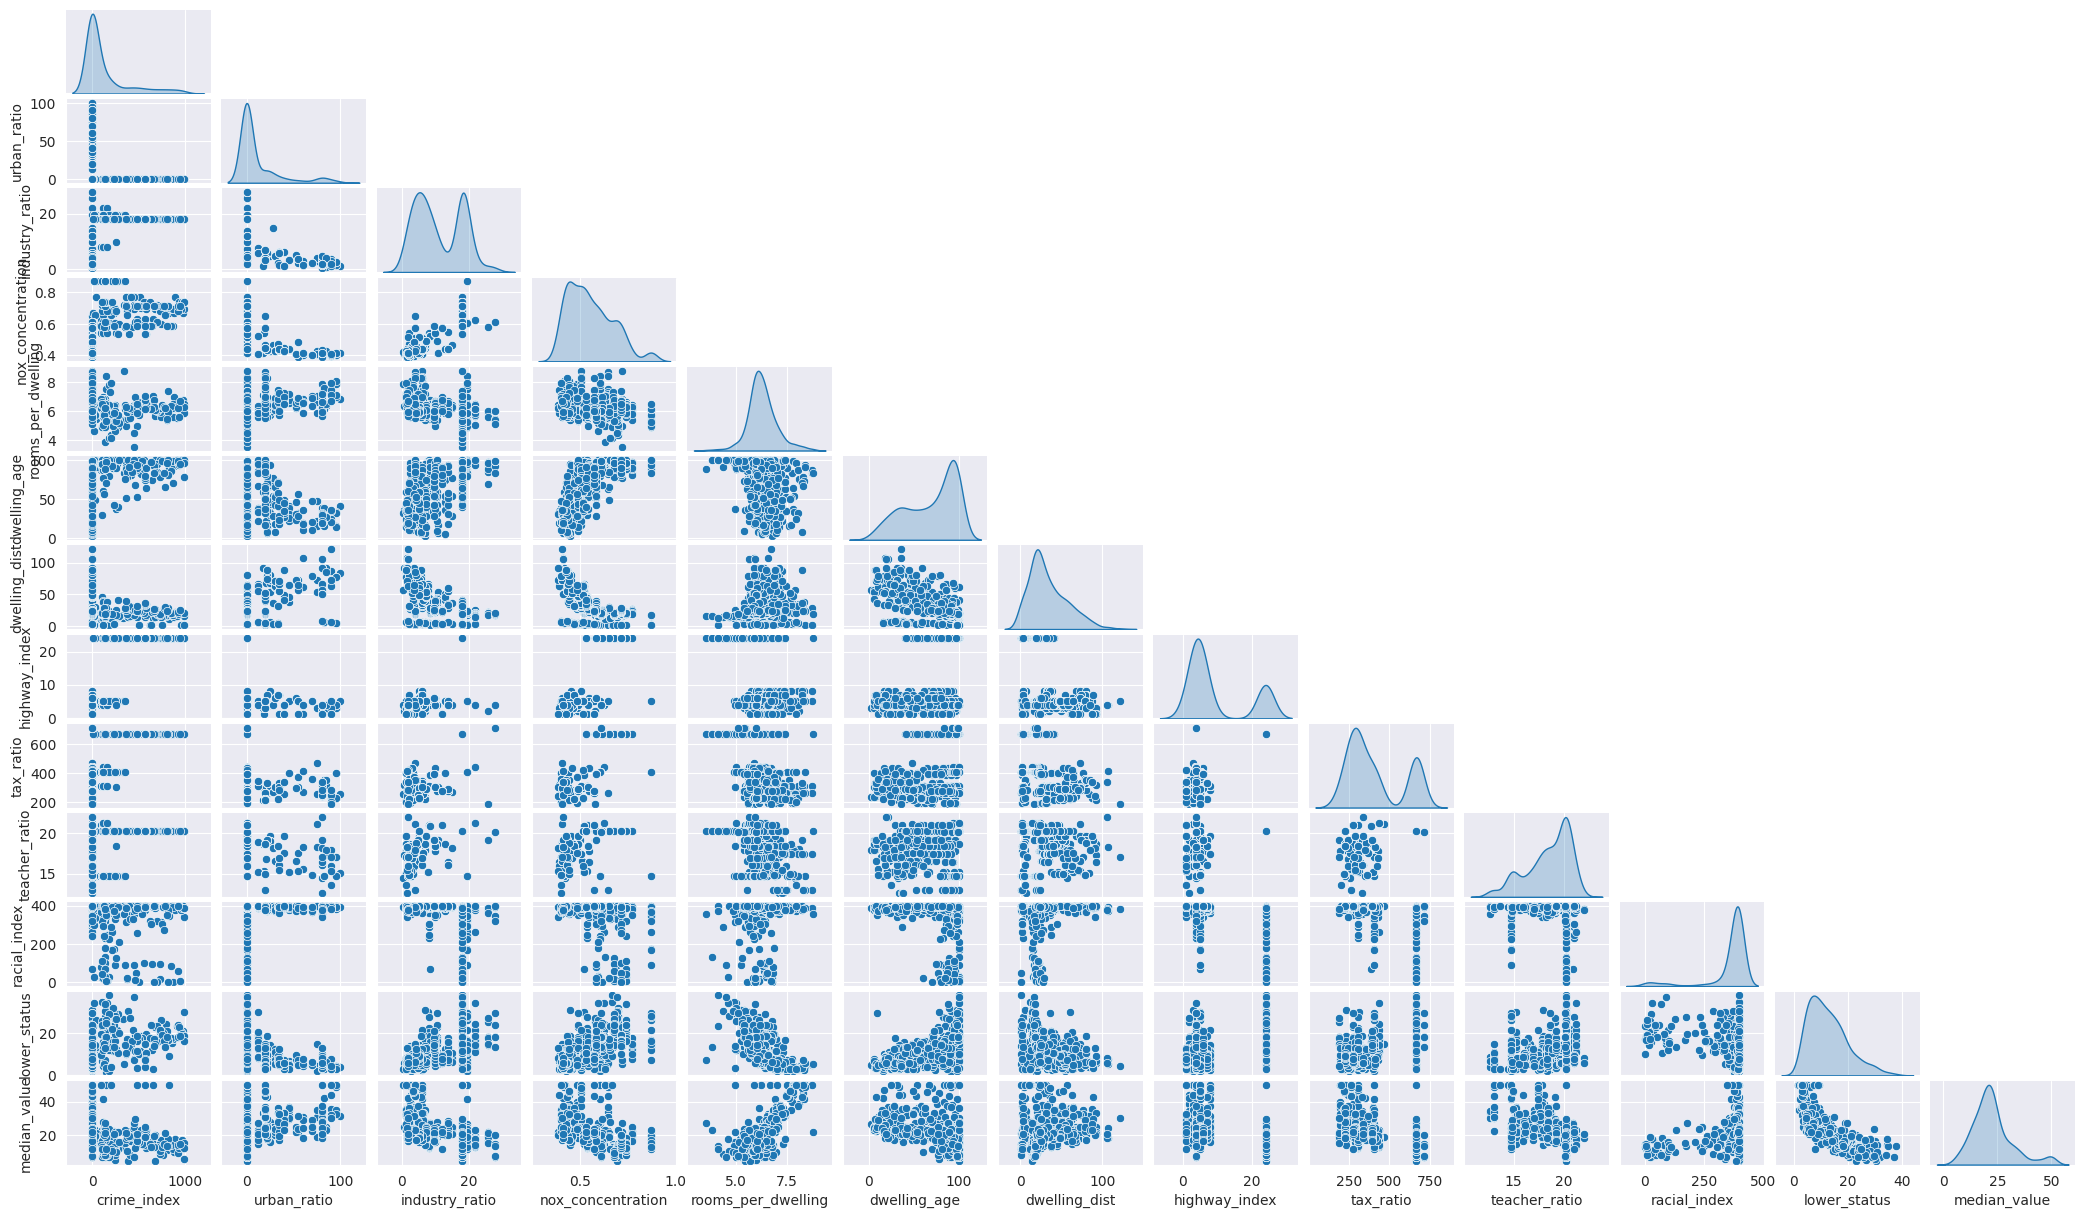

In [10]:
ax = sns.pairplot(data_float, diag_kind='kde', corner=True)
# labels size to 10
ax.fig.set_size_inches(21, 12)
for ax in ax.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=10)

plt.show()


El heatmap nos ayuda a entender fuerza y direccion de correlación entre las variables, mientras el pairplot nos ayuda a entender la distribucion de cada variable y la relacion entre cada par de variables, lo que nos puede ayudar a identificar relaciones no lineales entre las variables.

`crime_index` parece coincidir con `urban_ratio` parecen indicar presencia de inmuebles en zona rural son los que registran una tasa de criminalidad muy baja. El fenómeno es curioso y necesitamos explorar ambas variables para entender mejor esta relación.

Existen correlaciones positivas entre `median_value` y `rooms_per_dwelling`, ha mayor numero de habitaciones por vivienda, mayor precio. De igual manera una correlación negativa, ha mayor porcentaje de población de clase baja `lower_status`, menor precio promedio y a su vez, menor cantidad de habitaciones por vivienda. Zonas populares se prioriza la cantidad de viviendas por sobre la calidad de las mismas, lo que se traduce en un menor precio promedio de las viviendas.

`highway_index` tiene una correlación fuerte con la estrucutra urbana, donde `industry_ratio` , `tax_ratio` y `nox_concetration` nos indican relaciones interesantes, donde la mayor accesibilidad a autopistas esta relacionada con la zona industrial y por tanto, mayor concentracion de óxido nitroso y por tanto mayor recaudación al tratarse de zonas económicas. Esto explica a su vez la correlacion fuerte con `crime_index` y `lower_status` ya que las viviendas en zonas con alto indice industrial, suelen tener viviendas de menor calidad, con un tejido social mas vulnerable y por tanto, mayor tasa de criminalidad. Vemos a su vez esa correlación negativa tímica pero presente con `rooms_per_dwelling` y `medan_value`.

Con `dwelling_dist` existe una correlación negativa con respecto al `nox_concentration`, lo que indica a que a mayor distancia a los centros urbanos, menor concentración de óxido nitroso.

El resto de variables, parecen comportarse de forma mas dispera con respecto a otras, sin patrones claros de correlación, lo que puede indicar que no existe una relación lineal entre estas variables.

Print Dendograms and Clusters of Correlation Matrix

<Figure size 1200x800 with 0 Axes>

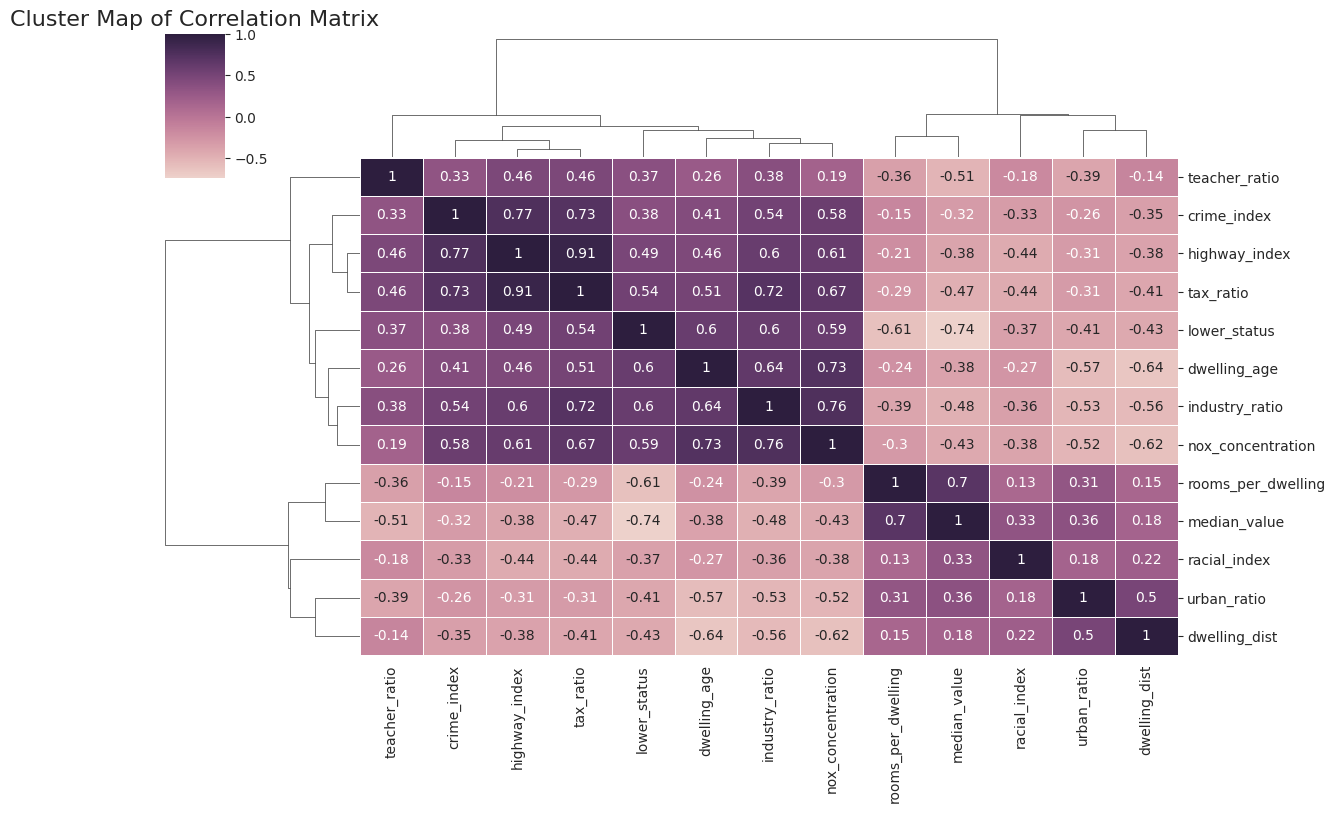

In [15]:
plt.figure(figsize=(12, 8), dpi=100)
sns.clustermap(
    corr_matrix, annot = True, cmap=sns.cubehelix_palette(as_cmap=True), linewidths = 0.5, figsize=(12, 8)
)
plt.title('Cluster Map of Correlation Matrix', fontsize = 16)

plt.show()

Aquí se confirma esa fuerza de correlaciones cuando lo organizamos a través de un cluster map o dendogramas. Encontramos como se agrupan las variables segun su fuerza de correlación y las primeras en agruparse son `urban_ratio` y `dwelling_dist`. `rooms_per_dwelling` con `median_value` como habíamos observado antes, pero tmabien el `industry_ratio` con `nox_concentration` donde su segunda fuerza de relación llega `dewelling_age`, esto puede sugerir cierto nivel de **multicolinealidad** entre las variables y afectar negativamente a la estabilidad de modelos lineales. 

A su vez, confirmamos una observacion anaterior, como `highway_index` se correlaciona en primer lugar con `tax_ratio` lo que supone una conexión posterior con `crime_index`. Finalmente, este pequeño custer va conecta con tda una seccion dedicada a la estructura urbana y calidad de vida con `industry_ratio`, `nox_concentration`, `dwelling_age` y `lower_status`. El dendograma sugiere por tanto, que todo lo anterior tiene como concecuencia natural en los niveles de calidad de la educación. 

## 2. PCA

Le dataset incluye por tanto 13 variables predictoras, lo que puede suponer un problema de dimensionalidad. Además, parece existir cierta multicolinalidad entre algunas variables, por lo que se antoja necesario realizar un proceso de reduccion de dimensionalidad con la finalidad de reducir el ruido de fondo y entender mejor la estructura subyacente de los datos. Para esto, vamos a utlizar el método de análisis de componentes principales (PCA), lo que nos permite reducir la dimensionalidad del dataset y a su vez entender cual es el aporte de varianza de cada una de las componentes principale y cuales son las variables que mas aportan a cada una de estas.

Se realiza a su vez una estandarización de los datos antes de aplicar el PCA, esto es necesario para que el PCA no se vea afectado por la escala de las variables. Se descartará el uso de variables categóricas binarias como `c_river_variable` para el PCA, ya que estas al arrojar valores de 0 y 1, la varianza de esta vaiable es muy baja y no aporta información relevante para la reducción de la dimensionalidad, el PCA espera vairables continuas, estas variables binarias terminarán siendo ignoradas.

Una vez estandarizados, aplicamos el PCA e iniciamos con la visualización de la varianza explicada acumulada para determinar el número óptimo de componentes principales a retener.

In [20]:
# import libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_float)

data_scaled = pd.DataFrame(data_scaled, columns=data_float.columns)

# Drop target variable
data_scaled = data_scaled.drop(columns=['median_value'])

# PCA instance and fit
pca = PCA()
pca.fit(data_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
# Cumulative explained variance
cumulative_explained_var = np.cumsum(explained_var)

Procedemos a visualizar la varianza explicada acumulada para determinar el número óptimo de componentes principales.

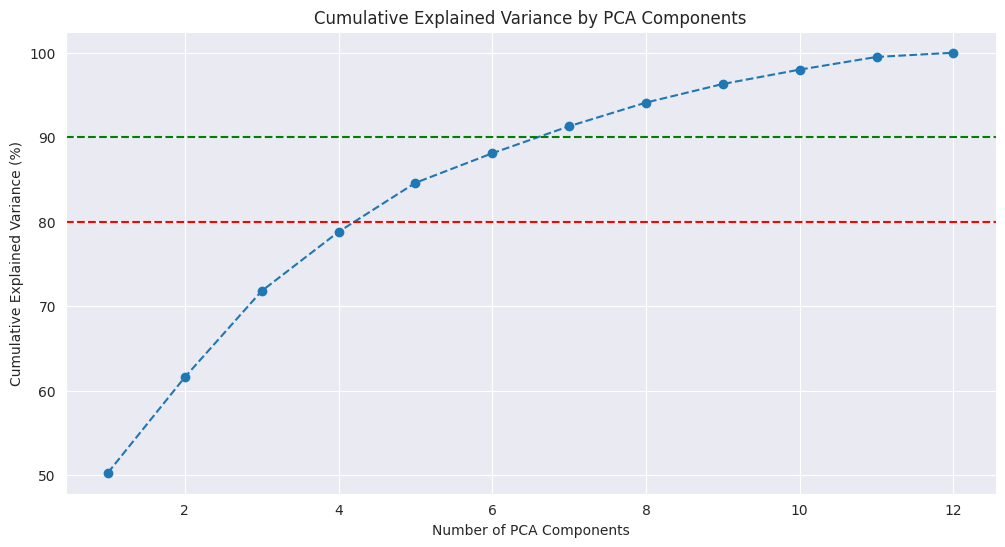

In [21]:
n_components = range(1, len(explained_var) + 1 )

plt.figure(figsize=(12, 6), dpi=100)
plt.plot(
    n_components,
    np.round(cumulative_explained_var * 100, 1),
    marker='o', linestyle='--'
    )

# Add horizontal line at 80% and 90% explained variance
plt.axhline(80, color='red', linestyle='--', label='80% Explained Variance')
plt.axhline(90, color='green', linestyle='--', label='90% Explained Variance')

plt.title('Cumulative Explained Variance by PCA Components', fontsize = 12)
plt.xlabel('Number of PCA Components', fontsize = 10)
plt.ylabel('Cumulative Explained Variance (%)', fontsize = 10)

plt.show()

Podemos observar que con 6 componentes, podemos explicar aproximadamente el 90% de la varianza, lo que puede ser un buen punto de corte para retener estas 6 componentes principales. Veamos cuales son entonces las variables que mas aportan a cada una de estas componentes principales para entender mejor la estructura subyacente de los datos.

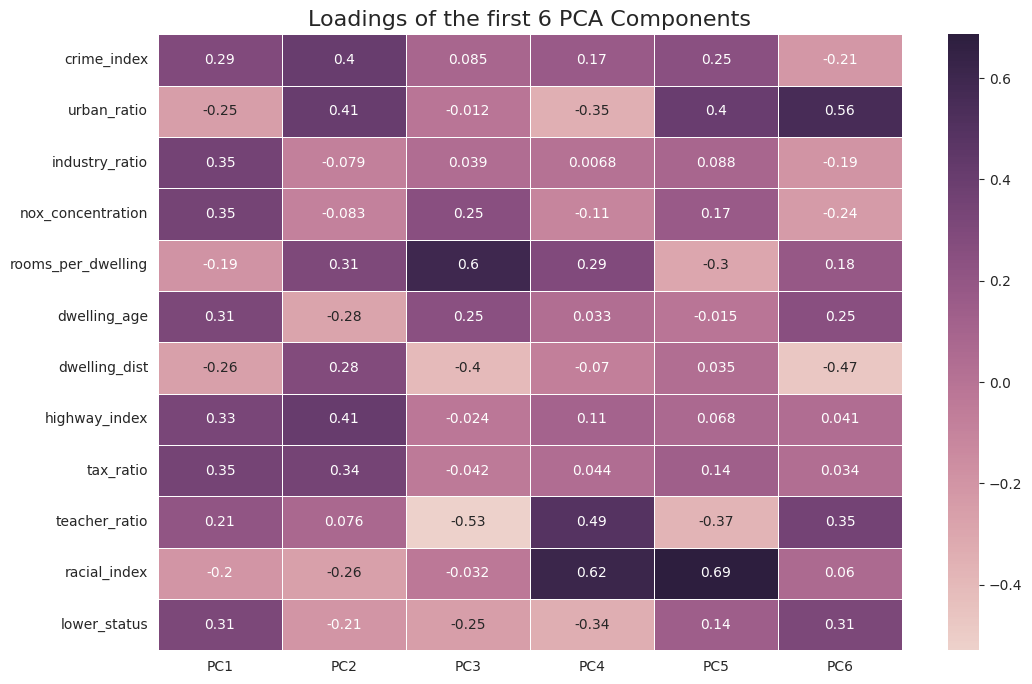

In [22]:
loadings = pd.DataFrame(
    np.round(pca.components_.T, 4),
    columns = [f'PC{i+1}' for i in range(len(explained_var))],
    index = data_scaled.columns
)

plt.figure(figsize=(12, 8), dpi=100)
sns.heatmap(loadings.iloc[:, :6], annot = True, cmap=sns.cubehelix_palette(as_cmap=True), linewidths = 0.5)
plt.title('Loadings of the first 6 PCA Components', fontsize = 16)
plt.show()

Un aspecto relevante del análisis es que ninguna variable puede descartarse de forma evidente, ya que todas contribuyen de manera significativa en al menos una de las componentes principales. Esto sugiere que el dataset presenta una estructura compleja donde distintas dimensiones capturan diferentes aspectos del sistema.

* PC1: Representa un eje asociado al grado de urbanización e intensidad industrial, con cargas relevantes en variables como `industry_ratio`, `nox_concentration`, `tax_ratio`, `crime_index` y `lower_status`. La distribución relativamente equilibrada de los pesos indica que esta componente captura una combinación de factores relacionados con condiciones de vida en entornos urbanos densos e industrializados.

* PC2: Se puede interpretar como un eje de accesibilidad y características de la vivienda, donde variables como `urban_ratio`, `rooms_per_dwelling`, `highway_index` y `tax_ratio` adquieren relevancia. Esta componente parece reflejar la relación entre conectividad, entorno urbano y calidad estructural de la vivienda.

* PC3: Está dominada principalmente por `rooms_per_dwelling`, lo que sugiere que representa un eje más específico de tamaño y calidad habitacional, actuando como una dimensión complementaria a las anteriores.

* PC4: Se asocia con factores socio-demográficos y educativos, con cargas importantes en `teacher_ratio` y `racial_index`, en oposición a variables como `lower_status` y `urban_ratio`. Esto sugiere un eje relacionado con desigualdad estructural y composición social.

En conjunto, las primeras componentes capturan dimensiones fundamentales como urbanización, calidad de la vivienda y estructura socioeconómica.

A medida que avanzamos hacia componentes posteriores, se observan patrones más específicos y menos dominantes, con mayor peso en variables como `racial_index`, `teacher_ratio` y `urban_ratio`. Estas componentes explican una menor proporción de la varianza total y parecen reflejar variaciones más locales o excepcionales, en lugar de estructuras globales del sistema.

## 3. ANOVA

Como hemos descartado anteriormente la variable categórica en `c_river_variable` para el análisis de componentes principales, ahora es necesario realizar un análisis de la varianza ANOVA para entender si existe una diferencia que pueda ser significativa en el precio de las viviendas `median_value` entre las zonas que colindan con un rio y las que no.

Para ello, se realiza una prueba de ANOVA de una vía, donde la variable dependiente es `median_value` y la variable independiente es `c_river_variable`. El objetivo es determinar si existe una diferencia estadísticamente significativa en el precio de las viviendas entre las zonas que colindan con un río y las que no.

Como solo tenemos un único factor, One Way ANOVA es el método estadístico seleccionado. Para ello vamos a utilizar la librería `statsmodels` de Python, que nos permite realizar este tipo de análisis de forma sencilla y obtener una tabla de ANOVA con los resultados con el $\text{f-statistic}$ y el $\text{p-value}$ para determinar si existe una diferencia significativa entre los grupos.

In [ ]:
# Import libraries for ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Perform One-Way ANOVA
model = ols('median_value ~ C(c_river_variable)', data=data).fit()  # in R formula  syntax
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq     df          F    PR(>F)
C(c_river_variable)   1312.079271    1.0  15.971512  0.000074
Residual             41404.216144  504.0        NaN       NaN


Estamos viendo, que el valor de $\text{f-statistic}$ tiene un valor alto y el $\text{p-value}$ está por debajo del umbral de significancia comúnmente utilizado $\alpha = 5%$, lo que indica que existe una diferencia estadísticamente, por lo tanto no se puede descartar la hipótesis alternativa, lo que sugiere que el hecho de colindar con un rio tiene un impacto significativo en el precio de las viviendas. 

Veamos en un boxplot la distribución de los precios en función del valor categórico de `c_river_variable` para entender mejor esta diferencia entre ambos grupos.

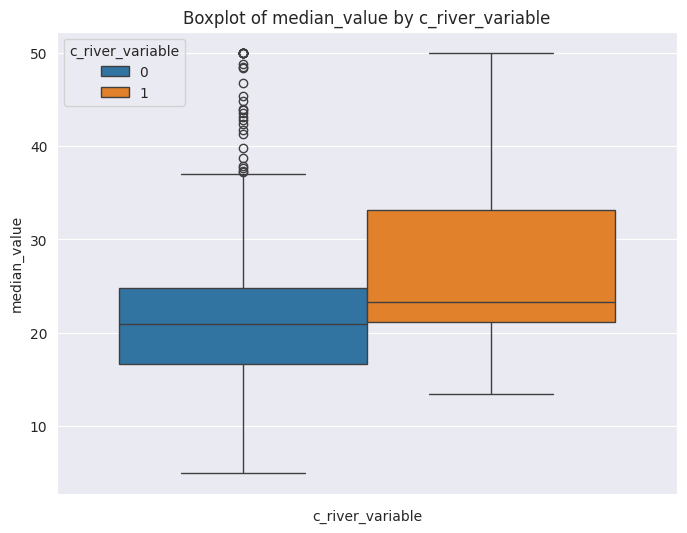

In [33]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

sns.boxplot(y = 'median_value', hue = 'c_river_variable', data = data, ax = ax)
ax.set_title('Boxplot of median_value by c_river_variable', fontsize = 12)
ax.set_xlabel('c_river_variable', fontsize = 10)
ax.set_ylabel('median_value', fontsize = 10)

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

plt.show()

Claramente podemos observar como las viviendas que colindan con un rio tienen un precio promedio mas alto que las que no colindan, se desplazan los quantiles hacia valores más alto. `c_river_variable` parece ser un factor importante a tener en cuenta y por lo tanto no debe ser descartado en el momento de construir el modelo de regresión.

## 4. Selección de Variables

En base a las observaciones anteriores y resultados del análisis de correlación, PCA y ANOVA, se llega a la conclusión de que todas las variables del datase aportan información relevante para la predicción del `median_value`.

1. Correlation Matrix:

El análisis de correlación mostró cierta relación entre algunas variables, dió indicios de multicolinaliedad entre ellas pero a su vez correlaciones negativas y positivas relevantes con la variable objetivo, lo que sugiere que las variables contienen información explicativa útil. En esta fase, no se identifican criterios suficientes para eliminar variable de forma individual.

1. PCA:

En esta fase, el análisis de las componentes muestra estrucutras subyacentes de calidad de vida, calidad de vivienda, estructura urbana y desigualdad social en las primeras 4 componentes principales, las cuales explican aproximadamente el 80% de la varianza total. No obstante, las cargas de las variables están distribuidas entre múltiples componentes, lo que ninguna variable domina completamente una dimensión específica, reforzando la idea de que todas aportan información relevante.

1. ANOVA:

Con la única variable categórica `c_river_variable`, se aplicó a un análisis de varianza para evaluar su impacto sobre `median_value`. Los resultados mostraron significancia estadística, indicando que esta variable también aporta información relevante.

**Conclusión:**

En su conjunto, los realizados no proporcionan evidencia suficiente para descartar variables de forma individual. Sin embargo, la presencia de multicolinealidad entre algunas de ellas pueden compartir información redundante, por lo que su impacto deberá evaluarse en el contexto del modelo de regresión.

Por lo tanto, en una primera versión, se utilizarán todas las variables dejando la selección final, sujeta al rendimiento y estabilidad del modelo.

## 5. Estudio de Regresión

Procedemos a realizar un modelo de regresión lineal múltiple. En un primer momento utilizaremos todas las variables predictoras disponibles para evaluar el rendimiento. Dependiendo de los resultados, se realizarán pruebas adicionales.

Para validar la regresion lineal, haremos las siguientes pruebas:

1. Normalidad de los residuos:
2. Homoscedasticidad:
3. No correlación de los residuos:
4. Ausencia de Outliers:

### 5.1 Modelo de Regresión Lineal Múltiple

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

Como no hemos eliminado outliers ni hemos realizado eliminación de variables, integramos en la data ya normalizada, la variable objetivo transformada con Box-Cox y `c_river_variable` como variable categórica binaria.

In [40]:
df = data_scaled.copy()

# insert median_value_cox and c_river_variable in df
df.insert(12, 'median_value_cox', data['median_value_cox'])
df.insert(0, 'c_river_variable', data['c_river_variable'])

Primero, debemos dividir el dataset en conjuntos de entrenamiento y prueba, para ello utilizaremos la función `train_test_split` de la librería `sklearn.model_selection`, reservando un 20% de los datos para el conjunto de prueba.Despues añadimos una constante a las variables predictoras para incluir el intercepto en el modelo.

In [54]:
# Train-test split
X = df.drop(columns=['median_value_cox'])
y = df['median_value_cox']

# Use 0.2 for test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Add constant to X_train for intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

Realizamos el ajuste del modelo en OLS y obtenemos el resumen de los resultados.

In [56]:
lr = sm.OLS(y_train, X_train_const).fit()

# Get y_pred
y_pred = lr.predict(X_test_const)
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:       median_value_cox   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     100.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          5.93e-116
Time:                        00:56:57   Log-Likelihood:                -164.45
No. Observations:                 404   AIC:                             356.9
Df Residuals:                     390   BIC:                             412.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.3230      0

Esto es un primer resultado, es un resultado bastante aceptable. La ventaja de utilizar OSL es que retorna todo una serie de información adicional sobre el modelo.

Tenemos un R-squared de 0.771, por tanto explica un 71% de la varianza total, el R-squared ajustado es de 0.762, lo que indica que se ajusta muy bien a los datos de entrenamiento. F-Statistic es de 100 con una porbabilidad muy baja, lo que indica que el modelo es significativo en su conjunto.

`lower_status` es sin duda la variable mas relevante, con un coeficiente de -0.4259, ha mayor proporción de población de clase baja, menor precio de vivienda. Confirmamos gran parte de los análisis anteriores, donde `lower_status`, `highway_index`, `tax_ratio`, `rooms_per_dwelling`, `teacher_ratio` y `c_river_variable` tienen coeficientes significativos. los p-values nos ofrecen informacion interesante, donde `urban_ratio` y `dwelling_dist` tienen valores (0.637 y 0.44 respectivamente) muy por encima del umbral de significancia $\alpha$, sugiere que no entregan inforamción relevante o son redundante con otros predictores, por tanto, son candidatas a ser eliminadas en una siguiente iteración del modelo.

Curiosamente, al ser evaluada en conjunto al resto de variables `c_river_variable` tiene un p-value en el borde de significancia, tambien es cantidata al descarte, pero el análisis de ANOVA previo y el boxplot mostraban una diferencia apreciable. En caso de ser descartada, será en una iteración posterior.

El mismo caso sucede `indsutry_ratio`, con un p-value de 0.074 podemos decidir retirarla de los datos de entrenamiento. Es posible que otras variables como `nox_concetration` y `highway_index` sean las que entregen información necesaria y esta resulta un indice redundate.

-----


Del lado de los residuos y otras métricas de validación.

* **Kurtosis** (6.68): es algo alta, lo que puede indicar la presencia de outliers y una distribución de los residuos con colas mas pesadas, lo cual compromete la normalidad. De igual manera validaremos esto con un test dedicado.
* **Jarque-Bera** (p-value ≈ 0): Tambien indica que los residuos no siguen una distribución normal, lo que puede afectar negativamente la validez de las inferencias.
* **Durbin-Watson** (1.868): Se ecunetra cerca de 2, valida que no exsite Auto Correlacion entre los residuos, es buena señal.
* **Cond. Number** (10.6): No parece haber problemas de **multicolinealidad** severa, es posible que eliminando algunas variables como las mencionadas, se reduzca aún más.

Falta por confirmar la homocedasticidad de los residuos, lo haremos mediante el test de Breusch-Pagan un poco mas adelante.


### 5.1 Validación de los residuos

Vamos a evaluar cada uno de los supuestos

##### 5.1.1 Normalidad de los residuos

La variable dependiente `median_value`  fue transformada originalmente con una transformación de Box-Cox para ajustarla a una distribución más cercana a la normal. Sin embargo, es necesario evaluar si los residuos del modelo de regresión lineal también cumplen con el supuesto de normalidad. Para ello, usaremos un QQ Plot y la prueba de Shapiro-Wilk para evaluar la normalidad de los residuos.

Las hipotésis para la prueba de Shapiro-Wilk son:

* H0: Los residuos siguen una distribución normal.
* H1: Los residuos siguen una distribución distintan a la normal.

In [62]:
# Load Libraries Shapiro-Wilk
from scipy.stats import shapiro

shapiro_test = shapiro(y_test - y_pred)
print('Shapiro-Wilk Test Statistic: ', shapiro_test.statistic)
print('Shapiro-Wilk Test p-value: ', shapiro_test.pvalue)

Shapiro-Wilk Test Statistic:  0.9588232075963495
Shapiro-Wilk Test p-value:  0.0029410613885784928


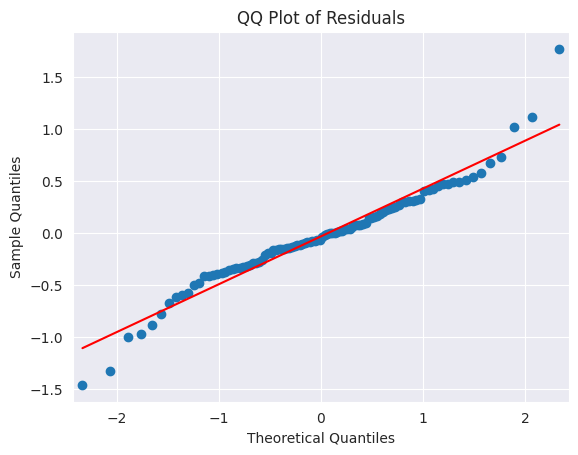

In [63]:
# View qq plot of the residuals
residuals = y_test - y_pred
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals', fontsize = 12)
plt.show()

Con un $\text{p-value}$ de 0.0029, no podemos rechazar la hipotesis nula, lo que indica que existen suficientes evidencias para rechazar la hiòtesis nula, tal como indicaban Jarque-Bera y Kurtosis. El QQ-Plot a su vez muestra esas colas pesadas en los residuos, que confirman la presencia de los outliers. Sin embargo, estas desviaciones no parecen ser severas y pueden deberse a su vez al los outliers que se han identificado en la variable objetivo, con valores trucados en $\approx 50$ que aun en Box-Cox, siguen teniendo efectos relevantes. 

Aquí se desprende otra sugerencia, realizar una eliminación de estos outliers para tener una distribución mas cercana a la normalidad. Esto puede mejorar el desempeño del modelo.

#### 5.1.2 Homoscedasticidad de los residuos

Necesitamos evaluar si los residuos poseen una varianza constante o homogénea a lo largo de los valores de predicción, esto valida que se trata de ruido de fondo y que no posee un patrón sistemático de fondo. Para ello, podemos utilizar el test de Breusch-Pagan. Para ello, utilizaremos la función de `het_breushpagan` de la librería `statsmodels.stats.diagnostic`, que nos permite realizar esta prueba de forma sencilla y obtener el valor del estadístico y el p-value en base a las siguientes hipótesis:

* H0: Los residuos tienen varianza constante (homoscedasticidad).
* H1: Los residuos no tienen varianza constante (heteroscedasticidad).

In [66]:
# Import library for Breusch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_test_const)

labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
bp_test_results = dict(zip(labels, bp_test))
print('Breusch-Pagan Test Results: ')
for key, value in bp_test_results.items():
    print(f'{key}: {np.round(value, 4)}')

Breusch-Pagan Test Results: 
Lagrange multiplier statistic: 26.0195
p-value: 0.0169
f-value: 2.3181
f p-value: 0.0107


El Test de Breusch-Pagan nos devuelve un p-value de 0.0169. Esto indica que existe evidencia suficiente para rechazar la hipotesis nula de homoscedasticidad, lo que sugiere que los residuos no tienen una varianza constante y se trata de una distribución de residuos heteroscedástica. Esto puede afectar negativamente la validez de las inferencias.

### 6. Conclusiones

El modelo de regresión lineal múltiple desarrollado proporciona una solida comprensión de los factores que influyen en el precio de las viviendas. Con un coeficiente de correlación elevado del 0.771, el modelo explica una gran proporción de la varianza en los precios de las viviendas, lo que indica un buen ajuste de los datos.  A su vez, los coeficientes valida lo explorado en el análisis de correlación y PCA, entregando información muy útil sobre las variables clave que describen las codiciones socioeconómicas, calidad de vida, calidad de la vivienda y el entorno urbano.

Sin embargo, el modelo presenta limitaciones importantes, como la presencia de residuos no normales y heteroscedásticos. Esto puede ser relacionadas por la presencia de valores atípicos (outliers) en la variable objetivo.

A su vez, la variables aportan información relevante, según los análisis de PCA y ANOVA, algunas de ellas resultan estadísticamente no significativas en el modelo de regresión, lo que indica una posible existencia de redunciancia y asoma la posibilidad de descartar algunas variaables. Lo que habre la puerta a futuras iteraciones del modelo.

En consecuencia, el modelo de regresión lineal múltiple, debe entenderse como una herramienta de aproximación explicativa del fenómeno, mas que una herramienta de predicción. Para asomar a la predicción, se deben realizar ajustes adicionales. Por tanto, el análisis realizado ha proporcionado una comprensión profunda de las estructuras subyacnetes y las relaciones entre las variables, identificando las dimensiones que gobiernan el comportameinto del mercado de viviendas en Boston.